## System Framing: Decision-Driven KYB Onboarding Workflow

This notebook simulates a KYB onboarding system from a system design perspective, rather than purely as a data analysis exercise.

The workflow is designed as a decision-driven architecture where:

* **Inputs:** customer profile data, documents, screening indicators and risk flags
* **Processing:** data validation, risk scoring, rule-based decision logic and workflow execution
* **Outputs:** Straight-Through Processing (STP), request for information, manual review, enhanced review or rejection

This reflects how modern onboarding systems are evolving from fully manual case handling toward structured, exception-based workflows, where decision-making is embedded directly into the onboarding process.

## KYB Onboarding STP Risk Scoring Engine

This project simulates a fintech KYB onboarding workflow using Python and SQL to demonstrate how manual onboarding processes can be redesigned into a scalable, decision-driven STP model.

The notebook covers:

* Simulation of a KYB onboarding pipeline
* Rule-based risk scoring and decision logic
* Exception routing for higher-risk cases
* Workflow bottleneck analysis using SQL
* Quantification of operational impact from manual review versus auto-approval

The overall objective is to show how onboarding operations can move from full manual handling toward exception-based processing, with low-risk and complete cases routed through Straight-Through Processing.

## Project Overview

This project uses synthetic KYB data to simulate customer applications, document collection, risk indicators, onboarding decisions and workflow progression.

Python is used to generate and process the simulated onboarding data, apply risk and decision logic, and model workflow execution. SQLite is used to analyse operational performance, including onboarding turnaround times, risk-driven delays and stage-level bottlenecks.

The project is structured to demonstrate the progression from:

**Customer application → Document validation → Risk assessment → Decisioning → Exception routing → Workflow execution → Operational analysis**

This creates an end-to-end view of how a rule-based KYB onboarding system can support Straight-Through Processing while routing higher-risk or incomplete cases for appropriate review.


In [235]:
# Import libraries for data generation, date handling, file management and analysis
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import os

# Set random seeds for reproducible synthetic data generation
random.seed(42)
np.random.seed(42)

In [236]:
# Create folders for generated datasets and analysis outputs
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created: data/, outputs/")

Folders created: data/, outputs/


## 1. Data Simulation (System Inputs Layer)

This section creates a synthetic population of business customers with attributes commonly reviewed during KYB onboarding, including geography, industry, entity type, ownership complexity, source of funds risk, screening indicators and expected transaction activity.

The synthetic population is designed so that selected higher-risk jurisdictions and industries have a greater probability of complex ownership structures, elevated source of funds risk and screening indicators. These relationships are scenario-based assumptions used to create realistic variation for workflow and decision-engine testing; they do not represent real-world risk rates.

In [237]:
# Define customer attributes used in the simulated onboarding population
countries = [
    "Singapore", "Hong Kong", "Malaysia", "Indonesia", "Philippines",
    "United Arab Emirates", "British Virgin Islands", "Cayman Islands"
]

industries = [
    "E-commerce", "Fintech", "Trading", "Consulting", "Gaming",
    "Digital Assets", "Payments", "Logistics", "Software", "Investment Holding"
]

entity_types = [
    "Private Limited Company", "LLC", "Partnership", "Sole Proprietorship"
]

ownership_levels = ["Low", "Medium", "High"]
sof_risk_levels = ["Low", "Medium", "High"]

# Define higher-risk segments for scenario-based simulation
high_risk_countries = {
    "British Virgin Islands",
    "Cayman Islands"
}

higher_risk_industries = {
    "Digital Assets",
    "Gaming",
    "Investment Holding"
}


# Generate a random application date within the past 120 days
def random_date(start_days_ago=120, end_days_ago=1):
    days_ago = random.randint(end_days_ago, start_days_ago)
    return (datetime.today() - timedelta(days=days_ago)).date()


num_customers = 120
customers = []

# Build a synthetic customer dataset with risk-sensitive attributes
for i in range(1, num_customers + 1):
    country = random.choice(countries)
    industry = random.choice(industries)
    entity_type = random.choice(entity_types)

    annual_revenue = random.randint(50_000, 5_000_000)
    expected_monthly_txn = random.randint(5_000, 500_000)

    # Identify whether the customer belongs to a higher-risk simulated segment
    is_higher_risk_segment = (
        country in high_risk_countries
        or industry in higher_risk_industries
    )

    # Apply scenario-based probability distributions
    if is_higher_risk_segment:
        ownership_complexity = np.random.choice(
            ownership_levels,
            p=[0.20, 0.40, 0.40]
        )
        source_of_funds_risk = np.random.choice(
            sof_risk_levels,
            p=[0.30, 0.40, 0.30]
        )
        pep_flag = np.random.choice(
            [0, 1],
            p=[0.85, 0.15]
        )
        sanctions_flag = np.random.choice(
            [0, 1],
            p=[0.97, 0.03]
        )
    else:
        ownership_complexity = np.random.choice(
            ownership_levels,
            p=[0.50, 0.35, 0.15]
        )
        source_of_funds_risk = np.random.choice(
            sof_risk_levels,
            p=[0.60, 0.30, 0.10]
        )
        pep_flag = np.random.choice(
            [0, 1],
            p=[0.95, 0.05]
        )
        sanctions_flag = np.random.choice(
            [0, 1],
            p=[0.995, 0.005]
        )

    customers.append({
        "customer_id": f"CUST{i:03d}",
        "company_name": f"Company_{i:03d}",
        "country": country,
        "industry": industry,
        "entity_type": entity_type,
        "annual_revenue_usd": annual_revenue,
        "expected_monthly_txn_usd": expected_monthly_txn,
        "pep_flag": int(pep_flag),
        "sanctions_flag": int(sanctions_flag),
        "ownership_complexity": ownership_complexity,
        "source_of_funds_risk": source_of_funds_risk,
        "created_date": random_date().isoformat()
    })

customers_df = pd.DataFrame(customers)

customers_df.head()

,customer_id,company_name,country,industry,entity_type,annual_revenue_usd,expected_monthly_txn_usd,pep_flag,sanctions_flag,ownership_complexity,source_of_funds_risk,created_date
0,CUST001,Company_001,Hong Kong,E-commerce,Partnership,2104301,122026,0,0,Low,High,2026-06-17
1,CUST002,Company_002,Hong Kong,Software,Private Limited Company,3589336,21663,0,0,Low,Low,2026-07-01
2,CUST003,Company_003,Hong Kong,Consulting,LLC,4289227,320631,0,0,Medium,Medium,2026-07-01
3,CUST004,Company_004,Indonesia,Software,Sole Proprietorship,1899189,240514,0,0,Medium,Low,2026-04-20
4,CUST005,Company_005,Philippines,E-commerce,LLC,3595146,183389,0,0,Low,Low,2026-05-30


In [238]:
# Validate simulated distribution of key risk indicators
customers_df[[
    "pep_flag",
    "sanctions_flag"
]].mean().round(3)

pep_flag          0.100
sanctions_flag    0.017
dtype: float64

In [239]:
# Compare ownership and source of funds risk distribution
customers_df[[
    "ownership_complexity",
    "source_of_funds_risk"
]].value_counts().head(10)

ownership_complexity  source_of_funds_risk
Low                   Low                     23
Medium                Low                     19
Low                   Medium                  15
High                  Medium                  15
Low                   High                    12
High                  Low                     12
Medium                Medium                  10
High                  High                     7
Medium                High                     7
Name: count, dtype: int64

In [240]:
# Save file 'data/customers.csv'
customers_df.to_csv("data/customers.csv", index=False)
print("Saved:", "data/customers.csv")
print("Shape:", customers_df.shape)

Saved: data/customers.csv
Shape: (120, 12)


In [241]:
# Review the geographic distribution of customers
customers_df["country"].value_counts()


country
Hong Kong                 23
United Arab Emirates      17
Indonesia                 15
Philippines               14
Singapore                 14
British Virgin Islands    14
Cayman Islands            12
Malaysia                  11
Name: count, dtype: int64

In [242]:
# Review the industry mix of the simulated customer population
customers_df["industry"].value_counts()

industry
Software              17
Trading               17
Digital Assets        13
Payments              11
Investment Holding    11
Consulting            11
Logistics             11
E-commerce            10
Fintech               10
Gaming                 9
Name: count, dtype: int64

In [243]:
# Inspect customers with key screening or elevated risk indicators
customers_df[
    (customers_df["sanctions_flag"] == 1)
    | (customers_df["pep_flag"] == 1)
    | (customers_df["ownership_complexity"] == "High")
    | (customers_df["source_of_funds_risk"] == "High")
].head(10)

,customer_id,company_name,country,industry,entity_type,annual_revenue_usd,expected_monthly_txn_usd,pep_flag,sanctions_flag,ownership_complexity,source_of_funds_risk,created_date
0,CUST001,Company_001,Hong Kong,E-commerce,Partnership,2104301,122026,0,0,Low,High,2026-06-17
6,CUST007,Company_007,Hong Kong,Digital Assets,Partnership,2268961,428167,0,0,Medium,High,2026-06-29
8,CUST009,Company_009,Philippines,Investment Holding,Partnership,4893180,105814,1,0,Low,High,2026-04-05
12,CUST013,Company_013,Philippines,Fintech,LLC,4530690,387272,1,0,Medium,Low,2026-06-03
13,CUST014,Company_014,Malaysia,Logistics,Sole Proprietorship,2314486,490171,0,0,High,Medium,2026-04-14
17,CUST018,Company_018,Cayman Islands,Trading,Partnership,1221304,134303,0,0,Low,High,2026-03-31
18,CUST019,Company_019,Philippines,Investment Holding,Sole Proprietorship,4945028,214400,0,0,Low,High,2026-05-19
20,CUST021,Company_021,Hong Kong,Trading,LLC,3591334,317690,0,0,High,Medium,2026-06-26
22,CUST023,Company_023,Singapore,Fintech,Partnership,2903598,63485,0,0,High,Low,2026-05-28
23,CUST024,Company_024,British Virgin Islands,Trading,Sole Proprietorship,77223,383584,0,0,High,Medium,2026-03-14


### Initial Observations

The generated customer population includes a mix of lower- and higher-risk profiles across different jurisdictions, industries, entity types and ownership structures. Offshore jurisdictions, digital asset businesses, complex ownership structures and elevated source of funds risk are represented in the sample, providing sufficient variation for subsequent document validation, risk scoring and decision-engine testing.

The screening and risk distributions are synthetic and scenario-based. They are intended to support system and workflow simulation rather than represent actual customer risk rates.

## 2. Create KYB Document Records

This section simulates document collection during onboarding. Each customer is assigned a standard set of required KYB documents, with different verification outcomes to reflect operational realities such as pending checks, rejected documents and incomplete document packs.

The document layer supports later assessment of whether a customer is eligible for Straight-Through Processing or should be routed for request-for-information or manual review.

In [244]:
# Define common document types requested during KYB onboarding
required_document_types = [
    "Certificate of Incorporation",
    "Business Registration",
    "Shareholder Register",
    "UBO Declaration",
    "Proof of Address"
]

document_statuses = ["Pending", "Verified", "Rejected"]

kyb_documents = []
doc_id_counter = 1

# Generate one record for each required document type per customer
for _, row in customers_df.iterrows():
    customer_id = row["customer_id"]
    created_date = datetime.strptime(row["created_date"], "%Y-%m-%d")

    for doc_type in required_document_types:

        # Most documents are verified, while some remain pending or are rejected
        status = np.random.choice(
            document_statuses,
            p=[0.18, 0.72, 0.10]
        )

        submission_date = created_date + timedelta(days=random.randint(1, 10))

        # Only verified documents receive a verification date
        if status == "Verified":
            verified_date = submission_date + timedelta(days=random.randint(1, 5))
        else:
            verified_date = None

        kyb_documents.append({
            "doc_id": f"DOC{doc_id_counter:04d}",
            "customer_id": customer_id,
            "document_type": doc_type,
            "document_status": status,
            "submission_date": submission_date.date().isoformat(),
            "verified_date": verified_date.date().isoformat() if verified_date else None
        })

        doc_id_counter += 1

kyb_documents_df = pd.DataFrame(kyb_documents)

kyb_documents_df.head()

,doc_id,customer_id,document_type,document_status,submission_date,verified_date
0,DOC0001,CUST001,Certificate of Incorporation,Verified,2026-06-25,2026-06-27
1,DOC0002,CUST001,Business Registration,Verified,2026-06-25,2026-06-30
2,DOC0003,CUST001,Shareholder Register,Verified,2026-06-27,2026-07-01
3,DOC0004,CUST001,UBO Declaration,Verified,2026-06-23,2026-06-24
4,DOC0005,CUST001,Proof of Address,Verified,2026-06-25,2026-06-28


In [245]:
# Save file 'data/kyb_documents.csv'
kyb_documents_df.to_csv("data/kyb_documents.csv", index=False)

print("Saved:", "data/kyb_documents.csv")
print("Shape:", kyb_documents_df.shape)

Saved: data/kyb_documents.csv
Shape: (600, 6)


In [246]:
# Check the distribution of document verification outcomes
kyb_documents_df["document_status"].value_counts()

document_status
Verified    425
Pending     114
Rejected     61
Name: count, dtype: int64

In [247]:
# Confirm each customer has one record for each required document type
kyb_documents_df.groupby("customer_id")["document_type"].nunique().value_counts()

document_type
5    120
Name: count, dtype: int64

In [248]:
# Check for duplicate document types per customer
int(
    kyb_documents_df.duplicated(
        subset=["customer_id", "document_type"]
    ).sum()
)

0

### Initial Observations

The document dataset assigns each customer a standard set of required KYB documents, creating a consistent basis for document-completeness and verification checks.

Most documents are verified, while a smaller proportion remain pending or rejected. These non-verified outcomes will later contribute to onboarding friction, request-for-information routing, manual review and STP eligibility decisions.


## 3. Assign Rule-Based Risk Flags

This section applies rule-based logic to generate onboarding risk flags. The flags reflect common escalation drivers such as high-risk jurisdictions, complex ownership, elevated source of funds risk, PEP exposure, sanctions indicators, unusual expected transaction activity, adverse media exposure and incomplete document verification.

These flags form the risk signal layer used later for risk scoring, decisioning and exception routing.

In [249]:
# Define risk indicators commonly used in onboarding and EDD reviews
flag_types = [
    "high_risk_jurisdiction",
    "complex_ubo",
    "high_source_of_funds_risk",
    "pep_exposure",
    "sanctions_indicator",
    "adverse_media",
    "unusual_expected_volume",
    "incomplete_docs"
]

risk_flags = []
flag_id_counter = 1

# Assign risk flags to each customer based on profile attributes, screening indicators and document outcomes
for _, row in customers_df.iterrows():
    customer_id = row["customer_id"]
    flags_for_customer = []

    # Flag offshore structures as higher-risk jurisdictions
    if row["country"] in high_risk_countries:
        flags_for_customer.append(("high_risk_jurisdiction", "High"))

    # Flag customers with highly complex ownership structures
    if row["ownership_complexity"] == "High":
        flags_for_customer.append(("complex_ubo", "High"))

    # Flag customers with elevated source of funds risk
    if row["source_of_funds_risk"] == "High":
        flags_for_customer.append(("high_source_of_funds_risk", "High"))

    # Flag PEP exposure
    if row["pep_flag"] == 1:
        flags_for_customer.append(("pep_exposure", "High"))

    # Flag sanctions indicator
    if row["sanctions_flag"] == 1:
        flags_for_customer.append(("sanctions_indicator", "High"))

    # Flag customers with elevated expected transaction volumes
    if row["expected_monthly_txn_usd"] > 300_000:
        flags_for_customer.append(("unusual_expected_volume", "Medium"))

    # Simulate adverse media exposure with higher probability for higher-risk profiles
    is_higher_risk_profile = (
        row["country"] in high_risk_countries
        or row["industry"] in higher_risk_industries
        or row["ownership_complexity"] == "High"
        or row["source_of_funds_risk"] == "High"
    )

    adverse_media_probability = 0.18 if is_higher_risk_profile else 0.05

    if random.random() < adverse_media_probability:
        flags_for_customer.append(("adverse_media", "High"))

    # Flag customers whose required KYB documents are not fully verified
    customer_docs = kyb_documents_df[
        kyb_documents_df["customer_id"] == customer_id
    ]

    all_required_docs_verified = (
        customer_docs["document_type"].nunique() == len(required_document_types)
        and (customer_docs["document_status"] == "Verified").all()
    )

    if not all_required_docs_verified:
        flags_for_customer.append(("incomplete_docs", "Medium"))

    # Store all triggered flags in the risk flag dataset
    for flag_type, severity in flags_for_customer:
        risk_flags.append({
            "flag_id": f"FLAG{flag_id_counter:04d}",
            "customer_id": customer_id,
            "flag_type": flag_type,
            "flag_severity": severity,
            "created_date": row["created_date"]
        })

        flag_id_counter += 1

risk_flags_df = pd.DataFrame(risk_flags)

risk_flags_df.head()

,flag_id,customer_id,flag_type,flag_severity,created_date
0,FLAG0001,CUST001,high_source_of_funds_risk,High,2026-06-17
1,FLAG0002,CUST002,incomplete_docs,Medium,2026-07-01
2,FLAG0003,CUST003,unusual_expected_volume,Medium,2026-07-01
3,FLAG0004,CUST004,incomplete_docs,Medium,2026-04-20
4,FLAG0005,CUST006,incomplete_docs,Medium,2026-05-17


In [250]:
# Save file 'data/risk_flags.csv'
risk_flags_df.to_csv("data/risk_flags.csv", index=False)
print("Saved:", "data/risk_flags.csv")
print("Shape:", risk_flags_df.shape)

Saved: data/risk_flags.csv
Shape: (247, 5)


In [251]:
# Review the distribution of flag types
risk_flags_df["flag_type"].value_counts()

flag_type
incomplete_docs              90
unusual_expected_volume      42
complex_ubo                  34
high_source_of_funds_risk    26
high_risk_jurisdiction       26
adverse_media                15
pep_exposure                 12
sanctions_indicator           2
Name: count, dtype: int64

In [252]:
# Review the mix of medium- and high-severity flags
risk_flags_df["flag_severity"].value_counts()

flag_severity
Medium    132
High      115
Name: count, dtype: int64

In [253]:
# Check how many flags appear per customer
risk_flags_df.groupby("customer_id").size().describe()

count    109.000000
mean       2.266055
std        1.068420
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
dtype: float64

In [254]:
# Inspect customers with the highest number of triggered flags
risk_flags_df.groupby("customer_id").size().sort_values(ascending=False).head(10)

customer_id
CUST036    5
CUST092    5
CUST098    5
CUST031    4
CUST024    4
CUST081    4
CUST061    4
CUST100    4
CUST101    4
CUST057    4
dtype: int64

### Initial Observations

The generated risk flags show which customers trigger onboarding escalation drivers such as incomplete document verification, elevated transaction activity, complex ownership, high source of funds risk, PEP exposure, sanctions indicators, adverse media or higher-risk jurisdictions.

Incomplete document verification is expected to be one of the most common triggers because STP eligibility requires all required documents to be verified. Higher-severity flags such as sanctions indicators, PEP exposure, adverse media and high-risk jurisdictions affect a smaller subset of customers and will be used later to support enhanced review or rejection logic.

## 4. Build Weighted Risk Scoring Engine

This section converts individual risk flags into a weighted customer-level risk score. Each flag is assigned a point value based on its relative severity and operational impact.

The resulting risk score and risk band will be used later to support onboarding decisioning, exception routing and workflow delay simulation.

In [255]:
# Define risk weights for each onboarding risk flag
risk_weights = {
    "incomplete_docs": 15,
    "unusual_expected_volume": 10,
    "complex_ubo": 20,
    "high_source_of_funds_risk": 20,
    "high_risk_jurisdiction": 20,
    "pep_exposure": 25,
    "adverse_media": 25,
    "sanctions_indicator": 100
}

# Apply weights to each triggered risk flag
risk_flags_df["risk_weight"] = risk_flags_df["flag_type"].map(risk_weights)

# Aggregate risk score at customer level
risk_score_df = (
    risk_flags_df
    .groupby("customer_id", as_index=False)["risk_weight"]
    .sum()
    .rename(columns={"risk_weight": "risk_score"})
)

# Ensure customers with no flags receive a risk score of zero
risk_score_df = customers_df[["customer_id"]].merge(
    risk_score_df,
    on="customer_id",
    how="left"
)

risk_score_df["risk_score"] = risk_score_df["risk_score"].fillna(0).astype(int)

# Apply hard-stop treatment for sanctions indicators
risk_score_df.loc[
    risk_score_df["customer_id"].isin(
        risk_flags_df.loc[
            risk_flags_df["flag_type"] == "sanctions_indicator",
            "customer_id"
        ]
    ),
    "risk_score"
] = 100

# Assign risk bands
def assign_risk_band(score):
    if score >= 70:
        return "High"
    elif score >= 35:
        return "Medium"
    else:
        return "Low"

risk_score_df["risk_band"] = risk_score_df["risk_score"].apply(assign_risk_band)

risk_score_df.head()

,customer_id,risk_score,risk_band
0,CUST001,20,Low
1,CUST002,15,Low
2,CUST003,10,Low
3,CUST004,15,Low
4,CUST005,0,Low


In [256]:
# Review customer risk band distribution
risk_score_df["risk_band"].value_counts()

risk_band
Medium    55
Low       52
High      13
Name: count, dtype: int64

In [257]:
# Inspect highest-risk customers
risk_score_df.sort_values("risk_score", ascending=False).head(10)

,customer_id,risk_score,risk_band
34,CUST035,100,High
118,CUST119,100,High
97,CUST098,95,High
35,CUST036,90,High
91,CUST092,90,High
80,CUST081,80,High
49,CUST050,80,High
100,CUST101,80,High
56,CUST057,75,High
60,CUST061,75,High


In [258]:
# Save updated risk flags with assigned risk weights
risk_flags_df.to_csv("data/risk_flags_weighted.csv", index=False)

print("Saved:", "data/risk_flags_weighted.csv")
print("Shape:", risk_flags_df.shape)

Saved: data/risk_flags_weighted.csv
Shape: (247, 6)


In [259]:
# Save file 'data/risk_scores.csv'
risk_score_df.to_csv("data/risk_scores.csv", index=False)

print("Saved:", "data/risk_scores.csv")
print("Shape:", risk_score_df.shape)

Saved: data/risk_scores.csv
Shape: (120, 3)


### Initial Observations

The weighted risk scoring engine converts individual onboarding risk flags into a customer-level risk score and risk band.

Low-risk customers are potential candidates for Straight-Through Processing, while medium- and high-risk customers require additional review or escalation. Sanctions indicators are treated as hard-stop triggers and assigned the highest risk score to support rejection or enhanced escalation logic.

## 5. Simulate Onboarding Workflow Events

This section creates a staged onboarding journey for each customer, from application submission through document collection, screening, analyst review, compliance review and final outcome.

Workflow delays are simulated using the customer’s risk band. Low-risk customers move faster, while medium- and high-risk customers experience longer processing times to reflect manual review, escalation and additional control checks.

Final workflow outcomes are linked to risk indicators rather than assigned randomly, making the process more consistent with the risk scoring layer.


In [260]:
# Define workflow stages before final outcome
workflow_stages = [
    "application_submitted",
    "docs_requested",
    "docs_received",
    "screening_completed",
    "analyst_review",
    "compliance_review"
]

# Define delay multipliers by risk band
risk_delay_factor = {
    "Low": 1.0,
    "Medium": 1.5,
    "High": 2.2
}

onboarding_events = []
event_id_counter = 1

# Combine customer data with risk score and band for workflow simulation
workflow_customers_df = customers_df.merge(
    risk_score_df,
    on="customer_id",
    how="left"
)

# Simulate the onboarding journey for each customer
for _, row in workflow_customers_df.iterrows():
    customer_id = row["customer_id"]
    base_date = datetime.strptime(row["created_date"], "%Y-%m-%d")
    current_date = base_date

    risk_band = row["risk_band"]
    delay_factor = risk_delay_factor[risk_band]

    # Simulate stage progression before final outcome
    for stage in workflow_stages:
        delay_days = max(1, int(random.randint(1, 3) * delay_factor))
        current_date += timedelta(days=delay_days)

        onboarding_events.append({
            "event_id": f"EVT{event_id_counter:04d}",
            "customer_id": customer_id,
            "stage": stage,
            "event_status": "Completed",
            "event_date": current_date.date().isoformat()
        })

        event_id_counter += 1

    # Determine final outcome based on risk indicators
    customer_flag_types = set(
        risk_flags_df.loc[
            risk_flags_df["customer_id"] == customer_id,
            "flag_type"
        ]
    )

    if "sanctions_indicator" in customer_flag_types:
        final_stage = "rejected"
    else:
        final_stage = "approved"

    current_date += timedelta(days=max(1, int(random.randint(1, 3) * delay_factor)))

    onboarding_events.append({
        "event_id": f"EVT{event_id_counter:04d}",
        "customer_id": customer_id,
        "stage": final_stage,
        "event_status": "Completed",
        "event_date": current_date.date().isoformat()
    })

    event_id_counter += 1

onboarding_events_df = pd.DataFrame(onboarding_events)

onboarding_events_df.head()

,event_id,customer_id,stage,event_status,event_date
0,EVT0001,CUST001,application_submitted,Completed,2026-06-18
1,EVT0002,CUST001,docs_requested,Completed,2026-06-21
2,EVT0003,CUST001,docs_received,Completed,2026-06-22
3,EVT0004,CUST001,screening_completed,Completed,2026-06-24
4,EVT0005,CUST001,analyst_review,Completed,2026-06-27


In [261]:
# Save file 'data/onboarding_events.csv'
onboarding_events_df.to_csv("data/onboarding_events.csv", index=False)

print("Saved:", "data/onboarding_events.csv")
print("Shape:", onboarding_events_df.shape)

Saved: data/onboarding_events.csv
Shape: (840, 5)


In [262]:
# Review the number of events captured at each stage
onboarding_events_df["stage"].value_counts()

stage
application_submitted    120
docs_requested           120
docs_received            120
screening_completed      120
analyst_review           120
compliance_review        120
approved                 118
rejected                   2
Name: count, dtype: int64

In [263]:
# Check how many workflow events were recorded per customer
onboarding_events_df.groupby("customer_id").size().value_counts()

7    120
Name: count, dtype: int64

In [264]:
# Review final workflow outcomes
onboarding_events_df[
    onboarding_events_df["stage"].isin(["approved", "rejected"])
]["stage"].value_counts()

stage
approved    118
rejected      2
Name: count, dtype: int64

### Initial Observations

The workflow simulation now links processing delays and final outcomes to the customer risk profile. Low-risk customers progress faster, while medium- and high-risk customers experience longer simulated delays due to additional review and control checks.

Final rejection is no longer assigned randomly. Customers with sanctions indicators are routed to rejection, while other customers proceed to approval in this workflow layer. Manual review and enhanced review routing will be handled in the decision-engine layer.


## 6. Load Datasets into SQLite

The generated datasets are loaded into SQLite so that operational, workflow and risk questions can be analysed using SQL. This mirrors how analysts often investigate customer, document, risk and workflow data across related tables in production environments.

The SQLite layer supports relational analysis across the full onboarding process, including customer profiles, document verification outcomes, triggered risk flags, customer-level risk scores and workflow events.


In [265]:
# Load generated datasets into SQLite for SQL-based analysis
import sqlite3

conn = sqlite3.connect("kyb_onboarding.db")

# Reset database tables to avoid stale outputs from earlier notebook runs
for table in [
    "customers",
    "kyb_documents",
    "risk_flags",
    "risk_scores",
    "onboarding_events",
    "decision_results"
]:
    conn.execute(f"DROP TABLE IF EXISTS {table}")

conn.commit()

customers_df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

kyb_documents_df.to_sql(
    "kyb_documents",
    conn,
    if_exists="replace",
    index=False
)

risk_flags_df.to_sql(
    "risk_flags",
    conn,
    if_exists="replace",
    index=False
)

risk_score_df.to_sql(
    "risk_scores",
    conn,
    if_exists="replace",
    index=False
)

onboarding_events_df.to_sql(
    "onboarding_events",
    conn,
    if_exists="replace",
    index=False
)

print("All tables loaded into SQLite")

All tables loaded into SQLite


In [266]:
# Confirm all expected tables were created
pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    conn
)

,name
0,customers
1,kyb_documents
2,onboarding_events
3,risk_flags
4,risk_scores


In [267]:
# Validate row counts across all SQLite tables
table_counts = pd.read_sql_query(
    """
    SELECT 'customers' AS table_name, COUNT(*) AS row_count FROM customers
    UNION ALL
    SELECT 'kyb_documents', COUNT(*) FROM kyb_documents
    UNION ALL
    SELECT 'risk_flags', COUNT(*) FROM risk_flags
    UNION ALL
    SELECT 'risk_scores', COUNT(*) FROM risk_scores
    UNION ALL
    SELECT 'onboarding_events', COUNT(*) FROM onboarding_events;
    """,
    conn
)

table_counts

,table_name,row_count
0,customers,120
1,kyb_documents,600
2,risk_flags,247
3,risk_scores,120
4,onboarding_events,840


## 7. Analyse Onboarding Performance with SQL

This section uses SQL to analyse onboarding turnaround times, compare processing duration across customer risk bands and identify workflow stages associated with longer delays.

The analysis demonstrates how relational onboarding data can be used to investigate operational performance, quantify the impact of risk-based processing and identify potential workflow friction points.


In [268]:
# Measure total onboarding duration for each customer
query = """
SELECT 
    customer_id,
    MIN(event_date) AS start_date,
    MAX(event_date) AS end_date,
    JULIANDAY(MAX(event_date)) - JULIANDAY(MIN(event_date)) AS onboarding_days
FROM onboarding_events
GROUP BY customer_id
ORDER BY onboarding_days DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,customer_id,start_date,end_date,onboarding_days
0,CUST081,2026-03-26,2026-04-25,30.0
1,CUST092,2026-03-22,2026-04-19,28.0
2,CUST057,2026-06-27,2026-07-23,26.0
3,CUST035,2026-06-05,2026-07-01,26.0
4,CUST111,2026-06-04,2026-06-28,24.0
5,CUST061,2026-05-15,2026-06-08,24.0
6,CUST050,2026-04-17,2026-05-11,24.0
7,CUST036,2026-05-09,2026-06-02,24.0
8,CUST018,2026-04-01,2026-04-24,23.0
9,CUST119,2026-03-25,2026-04-16,22.0


### Insight

The longest-running onboarding cases take between 22 and 30 days to complete. The subsequent risk-band analysis examines whether these longer processing timelines are associated with more complex customer risk profiles and additional review requirements.


In [269]:
# Compare risk band against total onboarding duration
query = """
WITH onboarding_duration AS (
    SELECT
        customer_id,
        JULIANDAY(MAX(event_date)) - JULIANDAY(MIN(event_date)) AS onboarding_days
    FROM onboarding_events
    GROUP BY customer_id
)
SELECT
    r.risk_band,
    COUNT(*) AS num_customers,
    ROUND(AVG(o.onboarding_days), 2) AS avg_onboarding_days,
    MIN(o.onboarding_days) AS min_days,
    MAX(o.onboarding_days) AS max_days
FROM risk_scores r
JOIN onboarding_duration o
    ON r.customer_id = o.customer_id
GROUP BY r.risk_band
ORDER BY avg_onboarding_days DESC;
"""

pd.read_sql(query, conn)

,risk_band,num_customers,avg_onboarding_days,min_days,max_days
0,High,13,24.15,20.0,30.0
1,Medium,55,16.44,9.0,23.0
2,Low,52,12.65,8.0,16.0


### Insight

Onboarding duration increases consistently across the simulated risk bands. High-risk customers average 24.15 days, compared with 16.44 days for medium-risk customers and 12.65 days for low-risk customers.

This pattern reflects the workflow design, where higher-risk cases experience additional simulated processing time for manual review, escalation and control checks. The results demonstrate how risk-based segmentation can be used to quantify operational workload and support queue prioritisation and exception-based case management.


In [270]:
# Count how many workflow events occur at each onboarding stage
query = """
SELECT 
    stage,
    COUNT(*) AS num_events
FROM onboarding_events
GROUP BY stage
ORDER BY num_events DESC;
"""

pd.read_sql(query, conn)

,stage,num_events
0,screening_completed,120
1,docs_requested,120
2,docs_received,120
3,compliance_review,120
4,application_submitted,120
5,analyst_review,120
6,approved,118
7,rejected,2


### Note

This view shows workflow volume by stage. Each customer passes through the six core workflow stages, while the final outcome is either approval or rejection.

A stage appearing frequently does not necessarily mean it is a bottleneck. Delay analysis is needed to identify where operational friction occurs.


In [271]:
# Calculate the average time gap between workflow stages
query = """
WITH stage_gaps AS (
    SELECT
        customer_id,
        stage,
        event_date,
        JULIANDAY(event_date) - JULIANDAY(
            LAG(event_date) OVER (
                PARTITION BY customer_id
                ORDER BY event_date
            )
        ) AS days_since_previous_stage
    FROM onboarding_events
)
SELECT
    stage,
    ROUND(AVG(days_since_previous_stage), 2) AS avg_days_between_stages
FROM stage_gaps
WHERE days_since_previous_stage IS NOT NULL
GROUP BY stage
ORDER BY avg_days_between_stages DESC;
"""

pd.read_sql(query, conn)

,stage,avg_days_between_stages
0,rejected,6.00
1,screening_completed,2.70
2,compliance_review,2.68
3,docs_requested,2.64
4,analyst_review,2.56
5,docs_received,2.54
6,approved,2.46


### Insight

The rejected outcome shows the longest average gap at 6.00 days, but this result is based on only two rejected customers and should therefore be interpreted cautiously.

Across the core workflow stages, the largest average gaps occur before screening completion (2.70 days) and compliance review (2.68 days), followed closely by document requests (2.64 days). These stages represent potential workflow friction points within the simulated process.

The differences between the core stages are relatively small, ranging from 2.54 to 2.70 days. This suggests that delays are distributed across the onboarding workflow rather than being concentrated in a single dominant bottleneck. In a production environment, these stage-level metrics could be monitored alongside case volumes, risk bands and service-level targets to identify where automation or process redesign would have the greatest operational impact.


In [272]:
# Compare average stage delays across customer risk bands
query = """
WITH stage_gaps AS (
    SELECT
        customer_id,
        stage,
        event_date,
        JULIANDAY(event_date) - JULIANDAY(
            LAG(event_date) OVER (
                PARTITION BY customer_id
                ORDER BY event_date
            )
        ) AS days_since_previous_stage
    FROM onboarding_events
)
SELECT
    r.risk_band,
    s.stage,
    COUNT(*) AS num_events,
    ROUND(AVG(s.days_since_previous_stage), 2) AS avg_days_between_stages
FROM stage_gaps s
JOIN risk_scores r
    ON s.customer_id = r.customer_id
WHERE s.days_since_previous_stage IS NOT NULL
GROUP BY
    r.risk_band,
    s.stage
ORDER BY
    CASE r.risk_band
        WHEN 'High' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'Low' THEN 3
    END,
    avg_days_between_stages DESC;
"""

pd.read_sql(query, conn)

,risk_band,stage,num_events,avg_days_between_stages
0,High,rejected,2,6.00
1,High,docs_requested,13,4.62
2,High,analyst_review,13,4.15
3,High,docs_received,13,4.00
4,High,compliance_review,13,3.85
5,High,approved,11,3.64
6,High,screening_completed,13,3.54
7,Medium,screening_completed,55,2.91
8,Medium,compliance_review,55,2.91
9,Medium,docs_requested,55,2.80


### Insight

Stage-level delays increase consistently with customer risk complexity. High-risk customers experience the longest processing gaps across the workflow, with particularly large average delays before document requests (4.62 days), analyst review (4.15 days) and document receipt (4.00 days).

Medium-risk customers show moderate delays of approximately 2.5 to 2.9 days across stages, while low-risk customers generally progress in approximately 1.9 to 2.3 days.

The rejected outcome records the longest average gap at 6.00 days, but this result is based on only two customers and should therefore be interpreted cautiously.

Overall, the analysis demonstrates how risk-based workflow segmentation can translate into different operational processing patterns. Within the simulated design, high-risk cases consume more processing time across multiple stages rather than creating delay at only one isolated point. This supports the use of early risk identification, differentiated service levels and exception-based queue management to allocate review capacity more effectively.


### 8. Build Decision Engine and Exception Routing Logic

This section applies rule-based decision logic to determine the appropriate onboarding route for each customer.

The decision engine combines customer risk score, risk band, screening indicators and document completeness to simulate how a KYB onboarding system can automate low-risk approvals while routing exceptions to the appropriate review queue.

The objective is not to remove manual review entirely, but to ensure that manual effort is focused on cases that require judgement, escalation or additional information.


In [273]:
# Build customer-level document completeness indicator
document_completeness_df = (
    kyb_documents_df
    .groupby("customer_id")
    .agg(
        total_documents=("document_type", "count"),
        verified_documents=("document_status", lambda x: (x == "Verified").sum()),
        pending_documents=("document_status", lambda x: (x == "Pending").sum()),
        rejected_documents=("document_status", lambda x: (x == "Rejected").sum())
    )
    .reset_index()
)

document_completeness_df["mandatory_docs_complete"] = (
    document_completeness_df["total_documents"] == len(required_document_types)
) & (
    document_completeness_df["verified_documents"] == len(required_document_types)
)

document_completeness_df["mandatory_docs_complete"] = (
    document_completeness_df["mandatory_docs_complete"].astype(int)
)

document_completeness_df.head()

,customer_id,total_documents,verified_documents,pending_documents,rejected_documents,mandatory_docs_complete
0,CUST001,5,5,0,0,1
1,CUST002,5,2,1,2,0
2,CUST003,5,5,0,0,1
3,CUST004,5,2,1,2,0
4,CUST005,5,5,0,0,1


In [274]:
# Combine customer profile, risk score and document completeness for decisioning
decision_input_df = (
    customers_df
    .merge(risk_score_df, on="customer_id", how="left")
    .merge(document_completeness_df, on="customer_id", how="left")
)

decision_input_df.head()

,customer_id,company_name,country,industry,entity_type,annual_revenue_usd,expected_monthly_txn_usd,pep_flag,sanctions_flag,ownership_complexity,source_of_funds_risk,created_date,risk_score,risk_band,total_documents,verified_documents,pending_documents,rejected_documents,mandatory_docs_complete
0,CUST001,Company_001,Hong Kong,E-commerce,Partnership,2104301,122026,0,0,Low,High,2026-06-17,20,Low,5,5,0,0,1
1,CUST002,Company_002,Hong Kong,Software,Private Limited Company,3589336,21663,0,0,Low,Low,2026-07-01,15,Low,5,2,1,2,0
2,CUST003,Company_003,Hong Kong,Consulting,LLC,4289227,320631,0,0,Medium,Medium,2026-07-01,10,Low,5,5,0,0,1
3,CUST004,Company_004,Indonesia,Software,Sole Proprietorship,1899189,240514,0,0,Medium,Low,2026-04-20,15,Low,5,2,1,2,0
4,CUST005,Company_005,Philippines,E-commerce,LLC,3595146,183389,0,0,Low,Low,2026-05-30,0,Low,5,5,0,0,1


In [275]:
# Define decision-routing logic
def decision_engine(row):
    if row["sanctions_flag"] == 1:
        return "Reject"
    elif row["mandatory_docs_complete"] == 0:
        return "Request Information"
    elif row["risk_band"] == "High":
        return "Enhanced Review"
    elif row["risk_band"] == "Medium":
        return "Manual Review"
    else:
        return "STP Auto-Approve"


def decision_reason(row):
    if row["sanctions_flag"] == 1:
        return "Sanctions indicator"
    elif row["mandatory_docs_complete"] == 0:
        return "Incomplete or unverified mandatory documents"
    elif row["risk_band"] == "High":
        return "High risk score"
    elif row["risk_band"] == "Medium":
        return "Medium risk score"
    else:
        return "Low risk and complete documentation"


decision_input_df["decision_route"] = decision_input_df.apply(decision_engine, axis=1)
decision_input_df["decision_reason"] = decision_input_df.apply(decision_reason, axis=1)

decision_results_df = decision_input_df[[
    "customer_id",
    "risk_score",
    "risk_band",
    "mandatory_docs_complete",
    "decision_route",
    "decision_reason"
]]

decision_results_df.head()

,customer_id,risk_score,risk_band,mandatory_docs_complete,decision_route,decision_reason
0,CUST001,20,Low,1,STP Auto-Approve,Low risk and complete documentation
1,CUST002,15,Low,0,Request Information,Incomplete or unverified mandatory documents
2,CUST003,10,Low,1,STP Auto-Approve,Low risk and complete documentation
3,CUST004,15,Low,0,Request Information,Incomplete or unverified mandatory documents
4,CUST005,0,Low,1,STP Auto-Approve,Low risk and complete documentation


In [276]:
# Review decision route distribution
decision_results_df["decision_route"].value_counts()

decision_route
Request Information    88
STP Auto-Approve       23
Manual Review           5
Reject                  2
Enhanced Review         2
Name: count, dtype: int64

#### Decision Priority Note

The routing logic applies a priority order. Sanctions indicators are treated as hard-stop rejection triggers. Document incompleteness is then checked before risk-band routing because a case cannot proceed to full review or approval until mandatory KYB documents are complete and verified.

As a result, some customers with medium or high risk scores may first be routed to Request Information. Once missing or rejected documents are resolved, the case can be re-assessed and routed to Manual Review, Enhanced Review or STP Auto-Approval depending on the remaining risk profile.


In [277]:
# Review decision route percentages
(
    decision_results_df["decision_route"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

decision_route
Request Information    73.33
STP Auto-Approve       19.17
Manual Review           4.17
Reject                  1.67
Enhanced Review         1.67
Name: proportion, dtype: float64

In [278]:
# Save decision results
decision_results_df.to_csv("data/decision_results.csv", index=False)

print("Saved:", "data/decision_results.csv")
print("Shape:", decision_results_df.shape)

Saved: data/decision_results.csv
Shape: (120, 6)


### Initial Observations

The decision-routing engine separates low-risk, document-complete customers from cases requiring additional handling. Customers with complete documentation and low risk are eligible for STP auto-approval, while customers with incomplete or unverified mandatory documents are routed for request-for-information.

Medium- and high-risk customers are routed to manual or enhanced review depending on their risk band, while sanctions indicators are treated as hard-stop rejection triggers.

This creates a structured exception-based onboarding model where analyst effort can be focused on incomplete, medium-risk, high-risk or rejected cases instead of reviewing every customer manually.


In [279]:
decision_results_df.to_sql(
    "decision_results",
    conn,
    if_exists="replace",
    index=False
)

print("decision_results table loaded into SQLite")

decision_results table loaded into SQLite


In [280]:
pd.read_sql_query(
    """
    SELECT decision_route, COUNT(*) AS num_customers
    FROM decision_results
    GROUP BY decision_route
    ORDER BY num_customers DESC;
    """,
    conn
)

,decision_route,num_customers
0,Request Information,88
1,STP Auto-Approve,23
2,Manual Review,5
3,Reject,2
4,Enhanced Review,2


### 9. Quantify STP and Manual Review Impact

This section evaluates the operational impact of the decision engine by comparing automated onboarding outcomes against cases requiring human intervention.

The analysis quantifies how many customers are eligible for Straight-Through Processing, how many require request-for-information or review handling, and how exception-based routing changes the manual workload profile.


In [281]:
query = """
SELECT
    decision_route,
    COUNT(*) AS num_customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM decision_results), 2) AS percentage
FROM decision_results
GROUP BY decision_route
ORDER BY num_customers DESC;
"""

pd.read_sql_query(query, conn)

,decision_route,num_customers,percentage
0,Request Information,88,73.33
1,STP Auto-Approve,23,19.17
2,Manual Review,5,4.17
3,Reject,2,1.67
4,Enhanced Review,2,1.67


In [282]:
query = """
SELECT
    CASE
        WHEN decision_route = 'STP Auto-Approve' THEN 'Automated'
        ELSE 'Manual / Exception Handling'
    END AS handling_type,
    COUNT(*) AS num_customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM decision_results), 2) AS percentage
FROM decision_results
GROUP BY handling_type;
"""

pd.read_sql_query(query, conn)

,handling_type,num_customers,percentage
0,Automated,23,19.17
1,Manual / Exception Handling,97,80.83


### Insight

The decision engine automatically approves 23 customers, representing 19.17% of the simulated onboarding population. These customers are low-risk and have complete mandatory KYB documentation.

The remaining 97 customers, or 80.83%, require manual or exception handling. Most of these cases are routed to Request Information because mandatory documents are pending, rejected or not fully verified.

This shows that STP is not only dependent on risk score. Document quality and completeness are major drivers of onboarding efficiency. In this simulation, improving document collection and verification would have the greatest impact on increasing the STP rate.


In [283]:
# Analyse exception-handling workload by customer risk band
query = """
SELECT
    risk_band,
    COUNT(*) AS num_exception_cases,
    ROUND(
        COUNT(*) * 100.0 /
        (
            SELECT COUNT(*)
            FROM decision_results
            WHERE decision_route != 'STP Auto-Approve'
        ),
        2
    ) AS percentage_of_exception_cases
FROM decision_results
WHERE decision_route != 'STP Auto-Approve'
GROUP BY risk_band
ORDER BY num_exception_cases DESC;
"""

pd.read_sql_query(query, conn)

,risk_band,num_exception_cases,percentage_of_exception_cases
0,Medium,55,56.7
1,Low,29,29.9
2,High,13,13.4


### Insight

Medium-risk customers account for the largest share of exception handling, representing 55 cases or 56.70% of the total exception workload. High-risk customers account for 13 cases or 13.40%.

A further 29 low-risk customers, representing 29.90% of exception cases, also require intervention. Because low-risk, document-complete customers are eligible for STP, these low-risk exceptions are driven primarily by incomplete or unverified mandatory documents rather than elevated customer risk.

This distinction highlights two different sources of operational workload: risk-driven review and document-driven friction. While medium- and high-risk cases require judgement and escalation, some low-risk cases could potentially be removed from manual queues through improved document collection, validation and verification processes.


In [284]:
# Separate document-driven friction from risk-driven review
query = """
SELECT
    CASE
        WHEN decision_route = 'Request Information'
            THEN 'Document-Driven Exception'
        WHEN decision_route IN ('Manual Review', 'Enhanced Review')
            THEN 'Risk-Driven Review'
        WHEN decision_route = 'Reject'
            THEN 'Hard-Stop Exception'
    END AS exception_type,
    COUNT(*) AS num_customers,
    ROUND(
        COUNT(*) * 100.0 /
        (
            SELECT COUNT(*)
            FROM decision_results
            WHERE decision_route != 'STP Auto-Approve'
        ),
        2
    ) AS percentage_of_exception_cases
FROM decision_results
WHERE decision_route != 'STP Auto-Approve'
GROUP BY exception_type
ORDER BY num_customers DESC;
"""

pd.read_sql_query(query, conn)

,exception_type,num_customers,percentage_of_exception_cases
0,Document-Driven Exception,88,90.72
1,Risk-Driven Review,7,7.22
2,Hard-Stop Exception,2,2.06


### Insight

Document-driven exceptions account for 88 cases, representing 90.72% of the total exception workload. By comparison, only 7 cases, or 7.22%, are routed directly to risk-driven manual or enhanced review, while 2 cases, or 2.06%, are treated as hard-stop exceptions.

The results indicate that the largest constraint on STP is not elevated customer risk, but document readiness. In the simulated workflow, incomplete or unverified mandatory documents prevent many customers from progressing directly to automated approval or risk-based review.

This suggests that the greatest opportunity to improve onboarding efficiency lies upstream in the process. Better document collection, automated completeness checks, document validation and targeted request-for-information workflows could reduce avoidable exception handling before analyst or compliance review is required.

The analysis also demonstrates why exception volume should not be treated as a single operational category. Document-driven cases require remediation and follow-up, while risk-driven cases require judgement and escalation. Separating these workloads allows onboarding teams to design different queues, service levels and automation strategies for each type of exception.


In [285]:
# Estimate potential STP eligibility if document-driven friction were resolved
query = """
SELECT
    risk_band,
    COUNT(*) AS num_customers,
    SUM(
        CASE
            WHEN risk_band = 'Low'
                 AND decision_route = 'Request Information'
            THEN 1
            ELSE 0
        END
    ) AS low_risk_document_exceptions
FROM decision_results
GROUP BY risk_band
ORDER BY
    CASE risk_band
        WHEN 'High' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'Low' THEN 3
    END;
"""

pd.read_sql_query(query, conn)

,risk_band,num_customers,low_risk_document_exceptions
0,High,13,0
1,Medium,55,0
2,Low,52,29


### Insight

All 29 low-risk exception cases are currently routed to Request Information because of document-related issues. This means that none of the low-risk exceptions require intervention because of elevated customer risk.

The result identifies a clear automation opportunity. If document completeness and verification issues were resolved, these 29 customers could potentially become eligible for STP, subject to the same decision rules and successful completion of any remaining validation checks.

Combined with the 23 customers already eligible for STP auto-approval, this creates a theoretical pool of 52 low-risk customers that could potentially be processed automatically.


In [286]:
# Compare current STP rate with potential STP rate
query = """
WITH stp_metrics AS (
    SELECT
        COUNT(*) AS total_customers,
        SUM(
            CASE
                WHEN decision_route = 'STP Auto-Approve'
                THEN 1 ELSE 0
            END
        ) AS current_stp_customers,
        SUM(
            CASE
                WHEN risk_band = 'Low'
                THEN 1 ELSE 0
            END
        ) AS potential_stp_customers
    FROM decision_results
)
SELECT
    total_customers,
    current_stp_customers,
    ROUND(
        current_stp_customers * 100.0 / total_customers,
        2
    ) AS current_stp_rate,
    potential_stp_customers,
    ROUND(
        potential_stp_customers * 100.0 / total_customers,
        2
    ) AS potential_stp_rate,
    ROUND(
        (potential_stp_customers - current_stp_customers)
        * 100.0 / total_customers,
        2
    ) AS potential_percentage_point_uplift
FROM stp_metrics;
"""

pd.read_sql_query(query, conn)

,total_customers,current_stp_customers,current_stp_rate,potential_stp_customers,potential_stp_rate,potential_percentage_point_uplift
0,120,23,19.17,52,43.33,24.17


### Insight

The current decision engine achieves an STP rate of 19.17%, with 23 of the 120 simulated customers eligible for automatic approval.

However, the analysis identifies a substantially larger theoretical automation opportunity. If document-related friction were resolved and all low-risk customers completed the required verification checks, up to 52 customers could potentially become eligible for STP. This would increase the theoretical STP rate to 43.33%, representing a 24.17 percentage-point uplift.

The result suggests that the greatest opportunity to expand STP is not necessarily to automate increasingly complex risk decisions. Instead, substantial improvement could be achieved by strengthening upstream document collection, completeness checks and verification processes so that more low-risk customers reach the decision engine in an STP-ready state.

This theoretical rate represents an upper-bound scenario within the current rule set rather than a guaranteed production outcome. In a live onboarding environment, additional controls, data-quality checks and policy requirements could affect final STP eligibility.


### 10. Simulate Future-State Document Automation Impact

This section models how improvements in document collection and verification could affect the STP rate.

The previous analysis identified 29 low-risk customers who are currently prevented from reaching STP because of incomplete or unverified mandatory documents. Rather than assuming that all document-related friction can be eliminated, this scenario analysis tests incremental improvement levels.

Four scenarios are modelled by assuming that 25%, 50%, 75% and 100% of the low-risk document exceptions are successfully resolved through improved document collection, automated completeness checks or verification processes.

The objective is to estimate how incremental reductions in document-driven friction could translate into higher STP rates and lower exception-handling workload.


In [287]:
# Define current-state metrics
total_customers = len(decision_results_df)

current_stp_customers = (
    decision_results_df["decision_route"] == "STP Auto-Approve"
).sum()

low_risk_document_exceptions = (
    (decision_results_df["risk_band"] == "Low")
    & (decision_results_df["decision_route"] == "Request Information")
).sum()

# Define document-friction resolution scenarios
resolution_scenarios = [0.25, 0.50, 0.75, 1.00]

scenario_results = []

for resolution_rate in resolution_scenarios:
    resolved_cases = round(
        low_risk_document_exceptions * resolution_rate
    )

    projected_stp_customers = (
        current_stp_customers + resolved_cases
    )

    projected_stp_rate = (
        projected_stp_customers / total_customers * 100
    )

    remaining_exception_cases = (
        total_customers - projected_stp_customers
    )

    scenario_results.append({
        "document_resolution_scenario": f"{int(resolution_rate * 100)}%",
        "resolved_low_risk_exceptions": resolved_cases,
        "projected_stp_customers": projected_stp_customers,
        "projected_stp_rate": round(projected_stp_rate, 2),
        "remaining_exception_cases": remaining_exception_cases
    })

scenario_impact_df = pd.DataFrame(scenario_results)

scenario_impact_df

,document_resolution_scenario,resolved_low_risk_exceptions,projected_stp_customers,projected_stp_rate,remaining_exception_cases
0,25%,7,30,25.00,90
1,50%,14,37,30.83,83
2,75%,22,45,37.50,75
3,100%,29,52,43.33,68


In [288]:
# Add current-state baseline for comparison
baseline_row = pd.DataFrame([{
    "document_resolution_scenario": "Current State",
    "resolved_low_risk_exceptions": 0,
    "projected_stp_customers": current_stp_customers,
    "projected_stp_rate": round(
        current_stp_customers / total_customers * 100,
        2
    ),
    "remaining_exception_cases": (
        total_customers - current_stp_customers
    )
}])

scenario_impact_df = pd.concat(
    [baseline_row, scenario_impact_df],
    ignore_index=True
)

scenario_impact_df

,document_resolution_scenario,resolved_low_risk_exceptions,projected_stp_customers,projected_stp_rate,remaining_exception_cases
0,Current State,0,23,19.17,97
1,25%,7,30,25.00,90
2,50%,14,37,30.83,83
3,75%,22,45,37.50,75
4,100%,29,52,43.33,68


### Insight

The scenario analysis shows a progressive increase in STP as document-related friction is reduced.

Resolving 25% of low-risk document exceptions increases the projected STP rate from 19.17% to 25.00%. At 50% resolution, the projected rate increases to 30.83%, while resolving 75% of these cases raises the projected STP rate to 37.50%.

Under the full-resolution scenario, 52 customers become potentially eligible for STP, increasing the projected rate to 43.33% and reducing the remaining exception workload from 97 to 68 cases.

The results demonstrate that operational improvement does not require the complete elimination of document friction. Incremental improvements in document collection and verification can progressively reduce exception volumes and increase automated processing.

The scenarios represent modelled outcomes rather than guaranteed production results. They assume that resolved low-risk document exceptions satisfy the remaining STP rules and do not develop new risk or screening issues during subsequent validation.


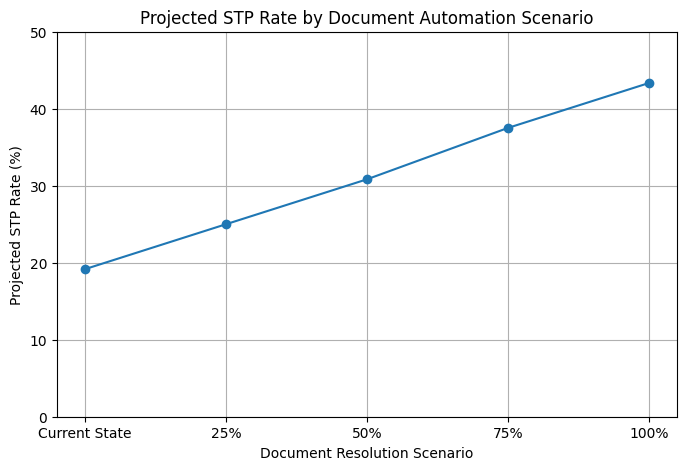

In [289]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    scenario_impact_df["document_resolution_scenario"],
    scenario_impact_df["projected_stp_rate"],
    marker="o"
)

plt.title("Projected STP Rate by Document Automation Scenario")
plt.xlabel("Document Resolution Scenario")
plt.ylabel("Projected STP Rate (%)")
plt.ylim(0, 50)
plt.grid(True)
plt.show()

In [290]:
scenario_impact_df.to_csv(
    "outputs/document_automation_scenario_impact.csv",
    index=False
)

print("Saved:", "outputs/document_automation_scenario_impact.csv")

Saved: outputs/document_automation_scenario_impact.csv


### 11. Estimate Manual Review Capacity Savings

This section translates the projected increase in STP into estimated operational capacity savings.

The model assigns a simplified handling-time assumption to each onboarding outcome. Cases processed through STP require minimal operational intervention, while request-for-information, manual review, enhanced review and rejection cases require progressively more human handling.

The objective is to estimate how reductions in low-risk document exceptions could reduce manual processing effort and release analyst capacity for higher-risk or more complex cases.

The handling-time assumptions are illustrative and are used only for scenario modelling. They do not represent actual production processing times.


In [291]:
# Define illustrative manual handling time assumptions in minutes
handling_time_minutes = {
    "STP Auto-Approve": 5,
    "Request Information": 45,
    "Manual Review": 90,
    "Enhanced Review": 180,
    "Reject": 120
}

handling_time_df = pd.DataFrame(
    list(handling_time_minutes.items()),
    columns=["decision_route", "handling_minutes"]
)

handling_time_df

,decision_route,handling_minutes
0,STP Auto-Approve,5
1,Request Information,45
2,Manual Review,90
3,Enhanced Review,180
4,Reject,120


In [292]:
# Estimate current-state operational handling time
current_workload_df = (
    decision_results_df
    .merge(
        handling_time_df,
        on="decision_route",
        how="left"
    )
)

current_workload_summary = (
    current_workload_df
    .groupby("decision_route")
    .agg(
        num_customers=("customer_id", "count"),
        handling_minutes_per_case=("handling_minutes", "first"),
        total_handling_minutes=("handling_minutes", "sum")
    )
    .reset_index()
)

current_workload_summary["total_handling_hours"] = (
    current_workload_summary["total_handling_minutes"] / 60
).round(2)

current_workload_summary.sort_values(
    "total_handling_minutes",
    ascending=False
)

,decision_route,num_customers,handling_minutes_per_case,total_handling_minutes,total_handling_hours
3,Request Information,88,45,3960,66.00
1,Manual Review,5,90,450,7.50
0,Enhanced Review,2,180,360,6.00
2,Reject,2,120,240,4.00
4,STP Auto-Approve,23,5,115,1.92


### Insight

Request-for-information handling represents the largest source of estimated operational effort, consuming 66.00 hours across 88 customers.

By comparison, manual review accounts for an estimated 7.50 hours, enhanced review for 6.00 hours and rejection handling for 4.00 hours. The 23 customers processed through STP require only an estimated 1.92 hours of total operational handling.

The results reinforce the earlier finding that document-driven friction is the main source of avoidable workload in the simulated onboarding process. Although enhanced review requires the highest handling time per individual case, the much larger volume of request-for-information cases creates the greatest aggregate capacity burden.

This distinction is important for process improvement. Automating only complex review activities may produce limited overall capacity benefits if high-volume document remediation continues to dominate operational effort.


In [293]:
# Calculate total current-state handling effort
current_total_minutes = current_workload_df["handling_minutes"].sum()
current_total_hours = current_total_minutes / 60

print("Current total handling minutes:", current_total_minutes)
print("Current total handling hours:", round(current_total_hours, 2))

Current total handling minutes: 5125
Current total handling hours: 85.42


In [294]:
# Estimate future-state capacity savings across document-resolution scenarios
capacity_scenario_results = []

for resolution_rate in resolution_scenarios:
    resolved_cases = round(
        low_risk_document_exceptions * resolution_rate
    )

    # Each resolved case moves from Request Information to STP Auto-Approve
    minutes_saved_per_case = (
        handling_time_minutes["Request Information"]
        - handling_time_minutes["STP Auto-Approve"]
    )

    total_minutes_saved = (
        resolved_cases * minutes_saved_per_case
    )

    projected_total_minutes = (
        current_total_minutes - total_minutes_saved
    )

    capacity_scenario_results.append({
        "document_resolution_scenario": f"{int(resolution_rate * 100)}%",
        "resolved_low_risk_exceptions": resolved_cases,
        "total_minutes_saved": total_minutes_saved,
        "total_hours_saved": round(total_minutes_saved / 60, 2),
        "projected_total_handling_hours": round(
            projected_total_minutes / 60,
            2
        )
    })

capacity_savings_df = pd.DataFrame(capacity_scenario_results)

capacity_savings_df

,document_resolution_scenario,resolved_low_risk_exceptions,total_minutes_saved,total_hours_saved,projected_total_handling_hours
0,25%,7,280,4.67,80.75
1,50%,14,560,9.33,76.08
2,75%,22,880,14.67,70.75
3,100%,29,1160,19.33,66.08


### Insight

The current-state workflow requires an estimated 85.42 hours of total operational handling across the 120 simulated customers.

As document-driven friction is progressively reduced, the model shows corresponding capacity savings. Resolving 25% of low-risk document exceptions saves an estimated 4.67 hours and reduces total handling effort to 80.75 hours. At 50% resolution, estimated savings increase to 9.33 hours.

Under the 75% resolution scenario, 14.67 hours of operational effort are released. If all 29 low-risk document exceptions are successfully resolved and routed to STP, the model estimates total savings of 19.33 hours, reducing overall handling effort from 85.42 hours to 66.08 hours.

This represents a reduction of approximately 22.63% in total estimated operational handling time under the full-resolution scenario.

The results demonstrate how relatively small improvements at the individual case level can create meaningful aggregate capacity benefits when applied to a high-volume source of operational friction. The released capacity could be redirected toward higher-risk customers, complex ownership structures, enhanced due diligence or other cases requiring analyst judgement.


In [295]:
# Calculate percentage reduction in total handling effort
capacity_savings_df["handling_time_reduction_pct"] = (
    capacity_savings_df["total_hours_saved"]
    / current_total_hours
    * 100
).round(2)

capacity_savings_df

,document_resolution_scenario,resolved_low_risk_exceptions,total_minutes_saved,total_hours_saved,projected_total_handling_hours,handling_time_reduction_pct
0,25%,7,280,4.67,80.75,5.47
1,50%,14,560,9.33,76.08,10.92
2,75%,22,880,14.67,70.75,17.17
3,100%,29,1160,19.33,66.08,22.63


In [296]:
# Add current-state baseline for capacity comparison
capacity_baseline_row = pd.DataFrame([{
    "document_resolution_scenario": "Current State",
    "resolved_low_risk_exceptions": 0,
    "total_minutes_saved": 0,
    "total_hours_saved": 0.00,
    "projected_total_handling_hours": round(current_total_hours, 2),
    "handling_time_reduction_pct": 0.00
}])

capacity_savings_df = pd.concat(
    [capacity_baseline_row, capacity_savings_df],
    ignore_index=True
)

capacity_savings_df

,document_resolution_scenario,resolved_low_risk_exceptions,total_minutes_saved,total_hours_saved,projected_total_handling_hours,handling_time_reduction_pct
0,Current State,0,0,0.00,85.42,0.00
1,25%,7,280,4.67,80.75,5.47
2,50%,14,560,9.33,76.08,10.92
3,75%,22,880,14.67,70.75,17.17
4,100%,29,1160,19.33,66.08,22.63


In [297]:
capacity_savings_df.to_csv(
    "outputs/capacity_savings_scenarios.csv",
    index=False
)

print("Saved:", "outputs/capacity_savings_scenarios.csv")

Saved: outputs/capacity_savings_scenarios.csv


### 12. Create Operational KPI Summary

This section consolidates the main outputs from the decision engine, STP analysis and capacity-savings model into a single operational KPI summary.

The purpose is to present the most important workflow findings in an executive-style view that can support process improvement discussion, automation prioritisation and operating model design.


In [298]:
kpi_summary = pd.DataFrame([
    {
        "KPI": "Current STP Rate",
        "Value": f"{current_stp_customers / total_customers * 100:.2f}%",
        "Interpretation": "Share of customers currently eligible for automated approval"
    },
    {
        "KPI": "Potential STP Rate",
        "Value": f"{scenario_impact_df.loc[scenario_impact_df['document_resolution_scenario'] == '100%', 'projected_stp_rate'].iloc[0]:.2f}%",
        "Interpretation": "Maximum STP rate if all low-risk document exceptions are resolved"
    },
    {
        "KPI": "Document-Driven Exception Share",
        "Value": "90.72%",
        "Interpretation": "Share of exception workload caused by document-related friction"
    },
    {
        "KPI": "Current Handling Effort",
        "Value": f"{current_total_hours:.2f} hours",
        "Interpretation": "Estimated current operational handling effort"
    },
    {
        "KPI": "Maximum Estimated Capacity Saved",
        "Value": "19.33 hours",
        "Interpretation": "Estimated handling time saved under full low-risk document-resolution scenario"
    },
    {
        "KPI": "Maximum Handling-Time Reduction",
        "Value": "22.63%",
        "Interpretation": "Estimated reduction in total handling effort under full-resolution scenario"
    }
])

kpi_summary

,KPI,Value,Interpretation
0,Current STP Rate,19.17%,Share of customers currently eligible for auto...
1,Potential STP Rate,43.33%,Maximum STP rate if all low-risk document exce...
2,Document-Driven Exception Share,90.72%,Share of exception workload caused by document...
3,Current Handling Effort,85.42 hours,Estimated current operational handling effort
4,Maximum Estimated Capacity Saved,19.33 hours,Estimated handling time saved under full low-r...
5,Maximum Handling-Time Reduction,22.63%,Estimated reduction in total handling effort u...


In [299]:
kpi_summary.to_csv(
    "outputs/operational_kpi_summary.csv",
    index=False
)

print("Saved:", "outputs/operational_kpi_summary.csv")

Saved: outputs/operational_kpi_summary.csv


### 13. Final Conclusion

This project demonstrates how a KYB onboarding workflow can be redesigned into a decision-driven operating model using Python, SQL and rule-based automation logic.

The simulated workflow shows how customer profile data, document verification outcomes, screening indicators and risk flags can be combined into a structured onboarding decision engine. Low-risk, document-complete customers are routed to STP auto-approval, while incomplete, medium-risk, high-risk or hard-stop cases are routed to the appropriate exception path.

The analysis shows that the current STP rate is 19.17%, but the theoretical STP opportunity could increase to 43.33% if low-risk document exceptions were resolved. This represents a 24.17 percentage-point uplift.

The largest operational constraint is document-driven friction. Document-related exceptions account for 90.72% of exception cases, while risk-driven reviews account for only 7.22%. This indicates that improving upstream document collection, validation and verification could have a greater impact than focusing only on downstream manual review.

The capacity model further shows that resolving all low-risk document exceptions could save an estimated 19.33 handling hours, reducing total estimated operational effort by 22.63%.

Overall, the project demonstrates how KYB onboarding can move from a fully manual case-handling model toward an exception-based workflow where automation handles low-risk, complete cases and analyst capacity is reserved for cases requiring judgement, escalation or enhanced review.


In [300]:
conn.close()
print("SQLite connection closed")

SQLite connection closed
